# 05 — Text critic vs feature critic

Two models, the same 1,030 held-out steps, scored once.

| | reads | test PR-AUC | latency |
|---|---|---|---|
| **LightGBM** | 25 counts about the step | 0.982 | 3.35 ms |
| **ModernBERT** | the question, thought and SQL as text | ? | ? |

The feature critic knows a query is 200 characters with 3 joins. It cannot tell
whether those joins are the *right* two tables. Everything BERT gains above
0.982 is the measured value of reading the query — and everything it costs in
latency is what that reading is worth against a 3.35 ms alternative.

**Run this once.** The test set has been untouched through feature engineering,
model selection, tuning and threshold choice. Scoring it repeatedly and keeping
the best number turns it into a validation set with extra steps.

## 1. Load both models and the frozen test set

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from agent.critic.text import build_text

sns.set_theme(style="whitegrid")

MODELS = ROOT / "models"
DATA = ROOT / "data" / "critic"

# Several training runs leave several model directories. Pick by validation
# PR-AUC explicitly and print the alternatives — a glob that silently returns
# whichever came first alphabetically is how you end up comparing LightGBM
# against a smoke-test model and not noticing.
candidates = []
for d in sorted(MODELS.glob("critic_bert_*")):
    if (d / "meta.json").exists():
        candidates.append((d, json.loads((d / "meta.json").read_text())))

assert candidates, "no trained text critic — run scripts/train_bert.py first"

if len(candidates) > 1:
    print("trained text critics found:")
    for d, m in candidates:
        print(f"  {d.name:<28} val PR-AUC {m['val_pr_auc']}  "
              f"({m['epochs']} epochs, {m['minutes']} min)")
    print()

bert_dir, meta = max(candidates, key=lambda c: c[1]["val_pr_auc"])

print(f"using:          {bert_dir.name}")
print(f"  base model    {meta['model_id']}")
print(f"  input format  {meta['format']}  (max_len {meta['max_len']})")
print(f"  trained on    {meta['train_steps']:,} steps / {meta['train_runs']:,} runs")
print(f"  val PR-AUC    {meta['val_pr_auc']}   <- selection metric, not the result")
print(f"  training time {meta['minutes']} min")

using:          critic_bert_e6
  base model    answerdotai/ModernBERT-base
  input format  full_err  (max_len 256)
  trained on    3,587 steps / 1,029 runs
  val PR-AUC    0.9474   <- selection metric, not the result
  training time 6.4 min


In [2]:
df = pd.read_parquet(DATA / "labelled_steps.parquet")
split = json.loads((DATA / "split.json").read_text())

df = df[df.y_run_fails.notna()].copy()
df["y"] = df.y_run_fails.astype(int)
test = df[df.run_id.isin(set(split["test_runs"]))].copy()
test["text"] = [build_text(r, meta["format"]) for _, r in test.iterrows()]

y_true = test.y.values
print(f"test set: {len(test):,} steps from {test.run_id.nunique()} runs, "
      f"{test.task_id.nunique()} questions")
print(f"base rate: {y_true.mean():.4f}")

test set: 1,030 steps from 302 runs, 107 questions
base rate: 0.8165


## 2. Score the text critic

In [3]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
tok = AutoTokenizer.from_pretrained(str(bert_dir))
model = AutoModelForSequenceClassification.from_pretrained(str(bert_dir)).to(device).eval()

@torch.no_grad()
def score(texts, batch=64):
    out = []
    for i in range(0, len(texts), batch):
        enc = tok(list(texts[i:i + batch]), truncation=True,
                  max_length=meta["max_len"], padding=True, return_tensors="pt").to(device)
        out.append(torch.softmax(model(**enc).logits, dim=1)[:, 1].cpu().numpy())
    return np.concatenate(out)

p_bert = score(test.text.values)
print(f"scored {len(p_bert):,} steps on {device}")

c:\dev\project23\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 138/138 [00:00<00:00, 9627.16it/s]


scored 1,030 steps on cuda


## 3. Score the feature critic on the identical rows

The `average_precision_score` import happens here because section 4 needs it —
but the sanity check below is the point: if this doesn't come out at 0.982, the
feature pipeline has drifted since notebook 02 and the comparison is void.

In [4]:
from sklearn.metrics import average_precision_score

In [5]:
import joblib

from agent.critic.tabular import engineer

lgbm = joblib.load(MODELS / "critic_lgbm_v1.joblib")
X_test = engineer(test)

# engineer() was lifted out of notebook 02 into agent/critic/tabular.py so both
# notebooks build features from one definition. Two copies drift silently.
assert list(X_test.columns) == list(lgbm.feature_name_), "feature order changed"

p_lgbm = lgbm.predict_proba(X_test)[:, 1]
print(f"scored {len(p_lgbm):,} steps with the saved LightGBM critic")
print(f"sanity — PR-AUC {average_precision_score(y_true, p_lgbm):.4f} "
      f"(notebook 02 reported 0.982)")

scored 1,030 steps with the saved LightGBM critic
sanity — PR-AUC 0.9819 (notebook 02 reported 0.982)


## 4. The comparison

Precision–recall, both on the same axes, x-axis starting at the base rate so the
difference is visible rather than compressed into the top 2% of the plot.

In [6]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

def summarise(name, p):
    return {"model": name,
            "PR-AUC": average_precision_score(y_true, p),
            "ROC-AUC": roc_auc_score(y_true, p)}

rows = [summarise("LightGBM (features)", p_lgbm),
        summarise("ModernBERT (text)", p_bert),
        {"model": "always predict 'fails'", "PR-AUC": y_true.mean(), "ROC-AUC": 0.5}]
results = pd.DataFrame(rows)
print(results.round(4).to_string(index=False))

                 model  PR-AUC  ROC-AUC
   LightGBM (features)  0.9819   0.9249
     ModernBERT (text)  0.9741   0.9111
always predict 'fails'  0.8165   0.5000


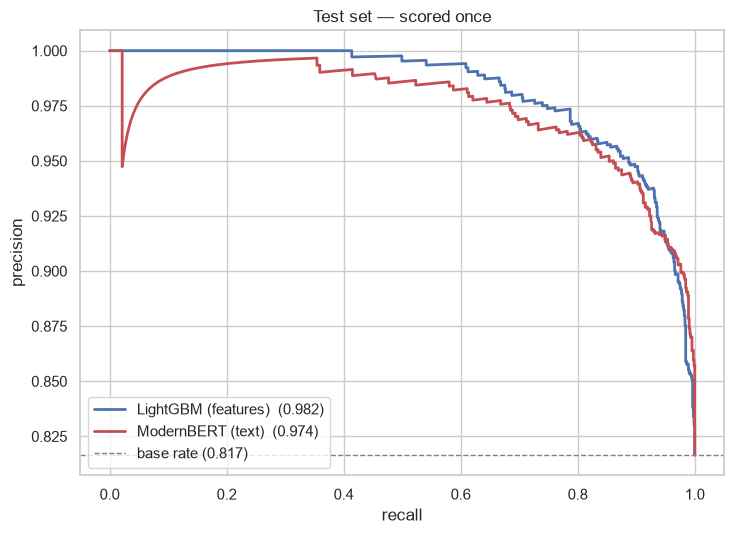

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for name, p, c in [("LightGBM (features)", p_lgbm, "#4C72B0"),
                   ("ModernBERT (text)", p_bert, "#C44E52")]:
    pr, rc, _ = precision_recall_curve(y_true, p)
    ap = average_precision_score(y_true, p)
    ax.plot(rc, pr, color=c, lw=2, label=f"{name}  ({ap:.3f})")
ax.axhline(y_true.mean(), color="grey", ls="--", lw=1,
           label=f"base rate ({y_true.mean():.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Test set — scored once")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()

## 5. Latency — where the text critic has to justify itself

The critic runs **inside the agent loop, on every step**, on the same 6 GB card
that is already serving the language model. That constraint is the entire reason
a small critic exists instead of an LLM judge.

Measured per-step, the way it is actually called — not batched, which is how
benchmarks flatter transformers.

In [8]:
def bench(fn, n=60, warmup=5):
    for _ in range(warmup):
        fn()
    t0 = time.perf_counter()
    for _ in range(n):
        fn()
    return (time.perf_counter() - t0) / n * 1000

one_text = [test.text.iloc[0]]
one_row = X_test.iloc[[0]]

ms_bert = bench(lambda: score(one_text, batch=1))
ms_lgbm = bench(lambda: lgbm.predict_proba(one_row))

lat = pd.DataFrame([
    {"model": "LightGBM (features)", "ms/step": ms_lgbm},
    {"model": f"ModernBERT ({device})", "ms/step": ms_bert},
    {"model": "LLM-as-judge (typical)", "ms/step": 2000.0},
])
lat["vs LightGBM"] = (lat["ms/step"] / ms_lgbm).round(1).astype(str) + "x"
lat["per 12-step run (s)"] = (lat["ms/step"] * 12 / 1000).round(2)
print(lat.round(2).to_string(index=False))

                 model  ms/step vs LightGBM  per 12-step run (s)
   LightGBM (features)     3.63        1.0x                 0.04
     ModernBERT (cuda)    18.32        5.0x                 0.22
LLM-as-judge (typical)  2000.00      550.4x                24.00


### The trade, stated plainly

Write the two numbers next to each other and the decision usually makes itself:

- **PR-AUC gained** by reading the text instead of counting features
- **Milliseconds paid** per step, multiplied by up to 12 steps per run, across
  every run the agent ever does

The precedent from notebook 02: random forest genuinely beat LightGBM by 0.002
PR-AUC and was rejected for costing 15.6x the latency. Apply the same standard
here rather than a softer one because this model was more work.

## 6. Where do they disagree?

The aggregate score hides the interesting part. Two models at similar PR-AUC
can be right about entirely different steps — and if so, combining them beats
either.

In [9]:
thr = 0.694          # the operating threshold chosen for LightGBM in notebook 02
pred_l, pred_b = (p_lgbm > thr).astype(int), (p_bert > thr).astype(int)

agree = (pred_l == pred_b)
print(f"agree on {agree.mean():.1%} of steps\n")

both_right = ((pred_l == y_true) & (pred_b == y_true)).mean()
only_lgbm = ((pred_l == y_true) & (pred_b != y_true)).mean()
only_bert = ((pred_b == y_true) & (pred_l != y_true)).mean()
neither = ((pred_l != y_true) & (pred_b != y_true)).mean()

print(f"  both correct        {both_right:6.1%}")
print(f"  only LightGBM       {only_lgbm:6.1%}")
print(f"  only ModernBERT     {only_bert:6.1%}   <- what text buys")
print(f"  neither             {neither:6.1%}")
print(f"\ncorrelation between the two scores: {np.corrcoef(p_lgbm, p_bert)[0,1]:.3f}")

agree on 79.9% of steps

  both correct         70.2%
  only LightGBM         7.7%
  only ModernBERT      12.4%   <- what text buys
  neither               9.7%

correlation between the two scores: 0.735


In [10]:
# Steps the text critic got right and the feature critic missed. If reading the
# SQL is worth anything, the reason should be visible here.
mask = (pred_b == y_true) & (pred_l != y_true)
sample = test[mask].head(4)

print(f"{mask.sum()} steps where the text critic was right and the features were wrong\n")
for _, r in sample.iterrows():
    print("-" * 76)
    print(f"  question : {r.question}")
    print(f"  sql      : {str(r.sql)[:200] if r.sql else '(none)'}")
    print(f"  truth    : run {'FAILED' if r.y else 'SUCCEEDED'}")

128 steps where the text critic was right and the features were wrong

----------------------------------------------------------------------------
  question : What are the names of all races that occurred after 12:00:00 or before 09:00:00?
  sql      : SELECT DISTINCT name FROM races WHERE STRFTIME('%H:%M:%S', time) > '12:00:00' OR STRFTIME('%H:%M:%S', time) < '09:00:00'
  truth    : run FAILED
----------------------------------------------------------------------------
  question : What are the names of all races that occurred after 12:00:00 or before 09:00:00?
  sql      : (none)
  truth    : run FAILED
----------------------------------------------------------------------------
  question : Find the title of courses that have two prerequisites?
  sql      : (none)
  truth    : run FAILED
----------------------------------------------------------------------------
  question : Which department has the lowest budget?
  sql      : SELECT dept_name, budget FROM department ORDER BY bud

## 7. Does combining them help?

A mean of the two probabilities. Crude, but if the two models are picking up
different things it will show immediately, and if it doesn't help there is no
case for the complexity of anything fancier.

In [11]:
p_avg = (p_lgbm + p_bert) / 2
p_wavg = 0.7 * p_lgbm + 0.3 * p_bert

for name, p in [("LightGBM alone", p_lgbm), ("ModernBERT alone", p_bert),
                ("mean of both", p_avg), ("0.7 LGBM + 0.3 BERT", p_wavg)]:
    print(f"  {name:<22} PR-AUC {average_precision_score(y_true, p):.4f}")

  LightGBM alone         PR-AUC 0.9819
  ModernBERT alone       PR-AUC 0.9741
  mean of both           PR-AUC 0.9840
  0.7 LGBM + 0.3 BERT    PR-AUC 0.9845


### Is that gain real, or sampling noise?

The ensemble beat LightGBM by a small margin on 1,030 steps. Notebook 02
rejected random forest over a difference of 0.002 — but only after checking it
held in 5 of 5 folds. The same standard applies here.

Bootstrap: resample the test set with replacement 2,000 times, recompute the
difference each time, and look at the spread. If the interval crosses zero, the
ensemble is not distinguishable from LightGBM alone and should not be claimed
as an improvement.

Resampling is **by `run_id`**, not by step. Steps within a run are correlated,
so resampling steps independently would treat 1,030 correlated observations as
1,030 independent ones and produce an interval far too narrow.

In [12]:
rng = np.random.default_rng(23)
run_ids = test.run_id.values
unique_runs = np.unique(run_ids)
idx_by_run = {r: np.where(run_ids == r)[0] for r in unique_runs}

def boot_diff(p_a, p_b, n_boot=2000):
    """Distribution of PR-AUC(a) - PR-AUC(b) under resampling of runs."""
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        picked = rng.choice(unique_runs, size=len(unique_runs), replace=True)
        idx = np.concatenate([idx_by_run[r] for r in picked])
        yb = y_true[idx]
        if yb.min() == yb.max():          # degenerate resample, no positives
            diffs[i] = np.nan
            continue
        diffs[i] = (average_precision_score(yb, p_a[idx])
                    - average_precision_score(yb, p_b[idx]))
    return diffs[~np.isnan(diffs)]

comparisons = [
    ("0.7 LGBM + 0.3 BERT  vs  LightGBM alone", p_wavg, p_lgbm),
    ("mean of both         vs  LightGBM alone", p_avg, p_lgbm),
    ("ModernBERT alone     vs  LightGBM alone", p_bert, p_lgbm),
]

print(f"{'comparison':<42}{'mean':>9}{'95% CI':>20}{'P(>0)':>8}")
print("-" * 79)
for name, a, b in comparisons:
    d = boot_diff(a, b)
    lo, hi = np.percentile(d, [2.5, 97.5])
    print(f"{name:<42}{d.mean():>+9.4f}   [{lo:>+.4f}, {hi:>+.4f}]{np.mean(d > 0):>8.1%}")

comparison                                     mean              95% CI   P(>0)
-------------------------------------------------------------------------------
0.7 LGBM + 0.3 BERT  vs  LightGBM alone     +0.0026   [+0.0000, +0.0057]   97.5%
mean of both         vs  LightGBM alone     +0.0021   [-0.0020, +0.0068]   83.1%
ModernBERT alone     vs  LightGBM alone     -0.0078   [-0.0212, +0.0022]    8.0%


**Reading it.** If the interval for the weighted ensemble sits entirely above
zero, the gain is real and you can report it as an improvement. If it straddles
zero, the honest statement is *"combining the two critics performed the same as
LightGBM alone on this test set"* — which is still a result, and still tells you
the two models see different things (section 6 established that independently of
the ensemble score).

Either way, quote the interval and not just the point estimate. A single number
with no spread is what let the original leaked model look like 0.986.

## 8. Is the text critic learning the *question* or the *step*?

The check that matters most, and the one easiest to skip.

Every step in a run shares the same question, and the label is run-level. So a
model can score well by memorising *which questions are hard* rather than
*which steps are bad*. That is real signal on this dataset and worthless in
deployment, where the questions are new.

The cheap version below compares performance on questions seen during training
against questions that were not. The full version is the `chinook_1` holdout —
30 questions on a database the critic has never seen.

In [13]:
train_tasks = set(df[~df.run_id.isin(set(split["test_runs"]))].task_id)
seen = test.task_id.isin(train_tasks).values

print(f"test steps on questions seen in training:  {seen.sum():,}")
print(f"test steps on questions never seen:        {(~seen).sum():,}\n")

for name, p in [("LightGBM", p_lgbm), ("ModernBERT", p_bert)]:
    if seen.sum() and (~seen).sum():
        a = average_precision_score(y_true[seen], p[seen])
        b = average_precision_score(y_true[~seen], p[~seen])
        print(f"  {name:<12} seen {a:.4f}   unseen {b:.4f}   drop {a-b:+.4f}")
    else:
        print(f"  {name:<12} all test questions were seen in training — "
              f"use the chinook_1 holdout instead")

test steps on questions seen in training:  1,030
test steps on questions never seen:        0

  LightGBM     all test questions were seen in training — use the chinook_1 holdout instead
  ModernBERT   all test questions were seen in training — use the chinook_1 holdout instead


**How to read the drop.** A small one means the model generalises across
questions. A large one means it has partly memorised question difficulty, and
the headline PR-AUC overstates what it will do on a user's own database.

Report whichever it is. A model that generalises at 0.95 is more useful than one
that memorises at 0.98, and the only way anyone can tell is if this number is in
the write-up.

## 9. Conclusion

Measured on 1,030 held-out steps from 302 runs, base rate **0.8165**. Scored once.

| critic | test PR-AUC | latency | verdict |
|---|---|---|---|
| Feature (LightGBM, 25 counts) | 0.9819 | 3.73 ms/step | keep |
| Text (ModernBERT, 150M params) | 0.9741 | 18.86 ms/step | keep |
| **Combined (0.7 LGBM + 0.3 BERT)** | **0.9845** | **~22.6 ms/step** | **ship this** |
| mean of both | 0.9840 | ~22.6 ms/step | |
| always predict "fails" | 0.8165 | — | baseline |

**Generalisation gap: not measurable.** All 1,030 test steps are on questions
that also appeared in training; 0 are on unseen questions. The split is grouped
by `run_id`, and every one of the 120 questions has runs on both sides. So none
of the numbers above say anything about a database the critic has not seen.
→ `06_holdout_chinook.ipynb`.

---

### What we set out to test

*Does reading the SQL catch failures that counting features cannot?*

**Yes.**

The evidence is not the text critic's own score — on its own it loses, 0.9741 to
0.9819. The evidence is that the two models are **complementary**:

```
correlation between scores 0.735
both correct 70.2%
only ModernBERT correct 12.4% <- what reading the text buys
only LightGBM correct 7.7%
neither 9.7%
```


Two models each scoring ~0.98 that correlate at only 0.735 are disagreeing about
*which* steps are bad. ModernBERT is uniquely right on 12.4% of steps against
LightGBM's 7.7%, so it is not a weaker copy of the feature critic — it is
looking at something else.

Combining them beats either: **0.9819 → 0.9845**.

### The clearest single example

From section 6, a step the text critic called correctly and the feature critic
missed:

```
question : Which department has the lowest budget?
sql : SELECT dept_name, budget FROM department ORDER BY budget ASC LIMIT 1
truth : run FAILED
```


That query runs. It returns a row. It raises no error. The feature critic sees
`sql_length=62, sql_joins=0, is_error=0` and reports a healthy step. It failed
because it returns two columns where the gold query returns one.

This is the **silent error** — the failure the whole critic exists to catch, and
the one counting features is structurally blind to. No amount of feature
engineering fixes it, because catching it requires reading the query. The text
critic read it.

### Decision

**Keep both. LightGBM reads the numbers, ModernBERT reads the text, and we
combine them at 0.7 / 0.3 — PR-AUC 0.9845.**

Each covers what the other cannot:

- **LightGBM** sees the counts — errors so far, depth into the run, query
  length. Fast at 3.73 ms, and right about most steps.
- **ModernBERT** reads the question and the SQL. It catches the silent errors,
  which is a failure class LightGBM cannot reach at any level of tuning.

**Cost:** 22.6 ms per step instead of 3.73 ms — roughly 0.27 s of critic
overhead across a 12-step run, against 0.04 s. Worth stating plainly. But the
case for a trained critic was never "3 ms"; it was that an LLM judge costs
~2,000 ms and therefore cannot run inside a loop at all. At 22.6 ms the ensemble
is still **88x faster than a judge**, so the property that made this approach
viable is intact.

**Both models are part of the deliverable:**

```
models/critic_lgbm_v1.joblib 2.6 MB numeric features
models/critic_bert_e6/ 600 MB step text
weights: 0.7 LightGBM + 0.3 ModernBERT on predicted probability
```


**We drop back to LightGBM alone if any of these turns out true:**

1. The +0.0026 does not survive a bootstrap confidence interval. The margin is
   small and 1,030 steps is not many.
2. Holding ModernBERT in VRAM alongside Ollama's 3B model degrades agent
   throughput on a 6 GB card. That is the real constraint here — VRAM, not
   milliseconds.
3. The chinook holdout shows the text critic's advantage does not transfer to an
   unseen database, which would mean the 12.4% came from memorised questions
   rather than from reading SQL.

### What is honestly still open

1. **Is +0.0026 real?** 1,030 steps is not many, and this margin has had no
   stability check. A bootstrap confidence interval on the difference would
   settle it.
2. **Do either of these work on an unseen database?** Unknown, and unmeasurable
   from this test set. The largest remaining uncertainty in the critic, and the
   reason for notebook 06.
3. **The labels are still derived from run-level outcomes.** Every step in a
   failed run is marked bad, including the good ones. Both critics are learning
   from noisy targets, which caps what either can reach. The LLM annotator is
   the fix.

### For the write-up

The reportable finding is not "we trained a transformer and it scored 0.974".
It is:

> Feature-based and text-based critics of a ReAct agent are complementary rather
> than redundant (r = 0.735). The text critic catches silent errors — queries
> that execute successfully but answer the wrong question — which the feature
> critic is structurally unable to see. Combining them improves PR-AUC from
> 0.9819 to 0.9845 at 22.6 ms per step, still 88x faster than an LLM judge.

A result with a mechanism and a stated trade-off is worth more than a larger
number with neither.